In [3]:
import numpy as np
import pandas as pd 

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [4]:
!pip install resampy
!pip install imblearn

In [5]:
import torch
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
import numpy as np
import pandas as pd
import os
import librosa 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import IPython
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.layers import Dense, Activation, Dropout #type:ignore
from tensorflow.keras.utils import to_categorical #type:ignore
from tensorflow.keras.callbacks import EarlyStopping #type:ignore

In [5]:
audio_files_path = "/kaggle/input/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/"

In [6]:
folders = os.listdir(audio_files_path)
print(folders)

['FAKE', 'REAL']


In [7]:
real_audio = "/kaggle/input/deep-voice-deepfake-voice-recognition/DEMONSTRATION/DEMONSTRATION/linus-original-DEMO.mp3"
fake_audio = "/kaggle/input/deep-voice-deepfake-voice-recognition/DEMONSTRATION/DEMONSTRATION/linus-to-musk-DEMO.mp3"

# Visualization

In [8]:
print("Real Audio:")
IPython.display.Audio(real_audio)

Real Audio:


In [9]:
print("Fake Audio:")
IPython.display.Audio(fake_audio)

Fake Audio:


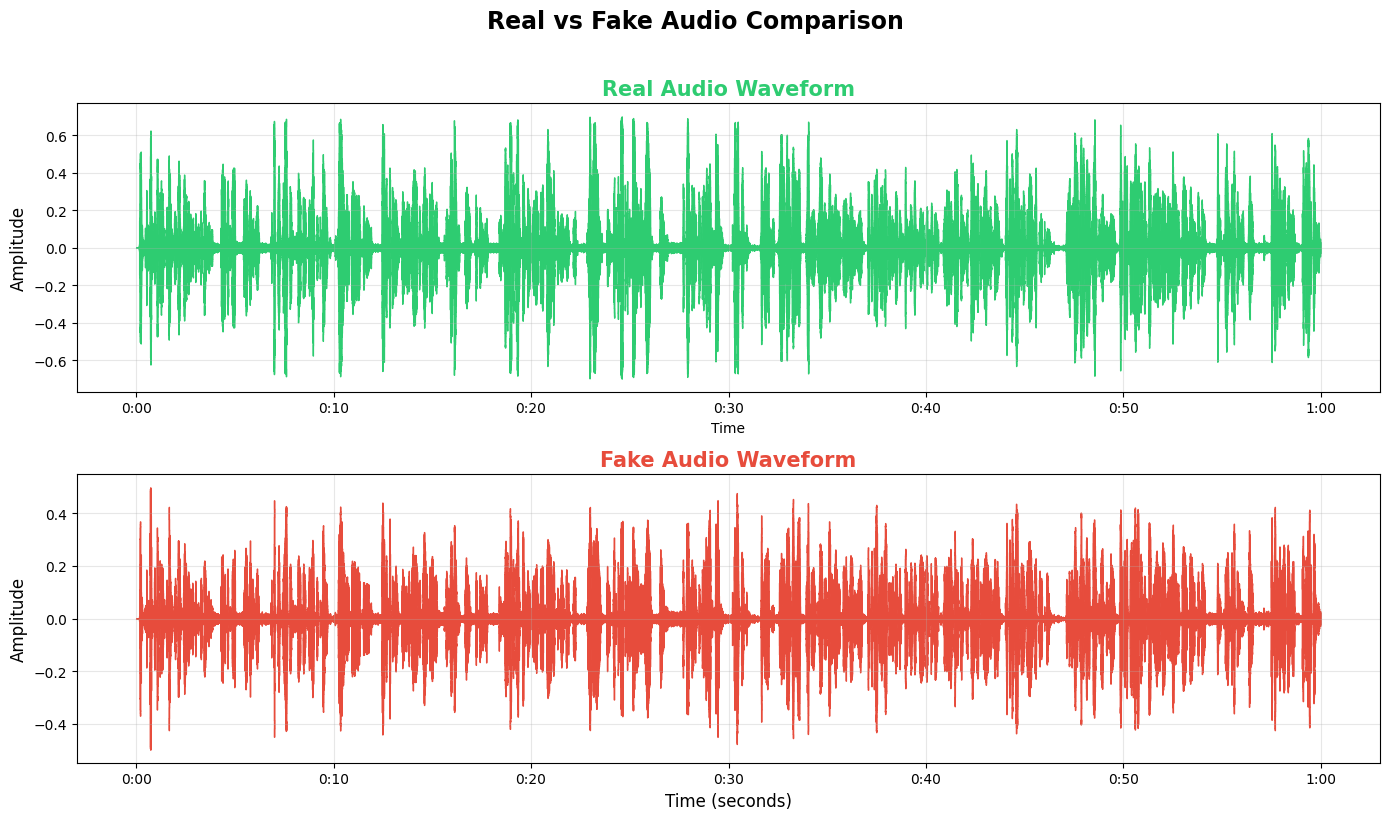

In [10]:
import librosa.display

real_ad, real_sr = librosa.load(real_audio, sr=None)
fake_ad, fake_sr = librosa.load(fake_audio, sr=None)

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
librosa.display.waveshow(real_ad, sr=real_sr, color="#2ecc71")
plt.title("Real Audio Waveform", fontsize=15, fontweight='bold', color="#2ecc71")
plt.ylabel("Amplitude", fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
librosa.display.waveshow(fake_ad, sr=fake_sr, color="#e74c3c")
plt.title("Fake Audio Waveform", fontsize=15, fontweight='bold', color="#e74c3c")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(alpha=0.3)

plt.suptitle("Real vs Fake Audio Comparison", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


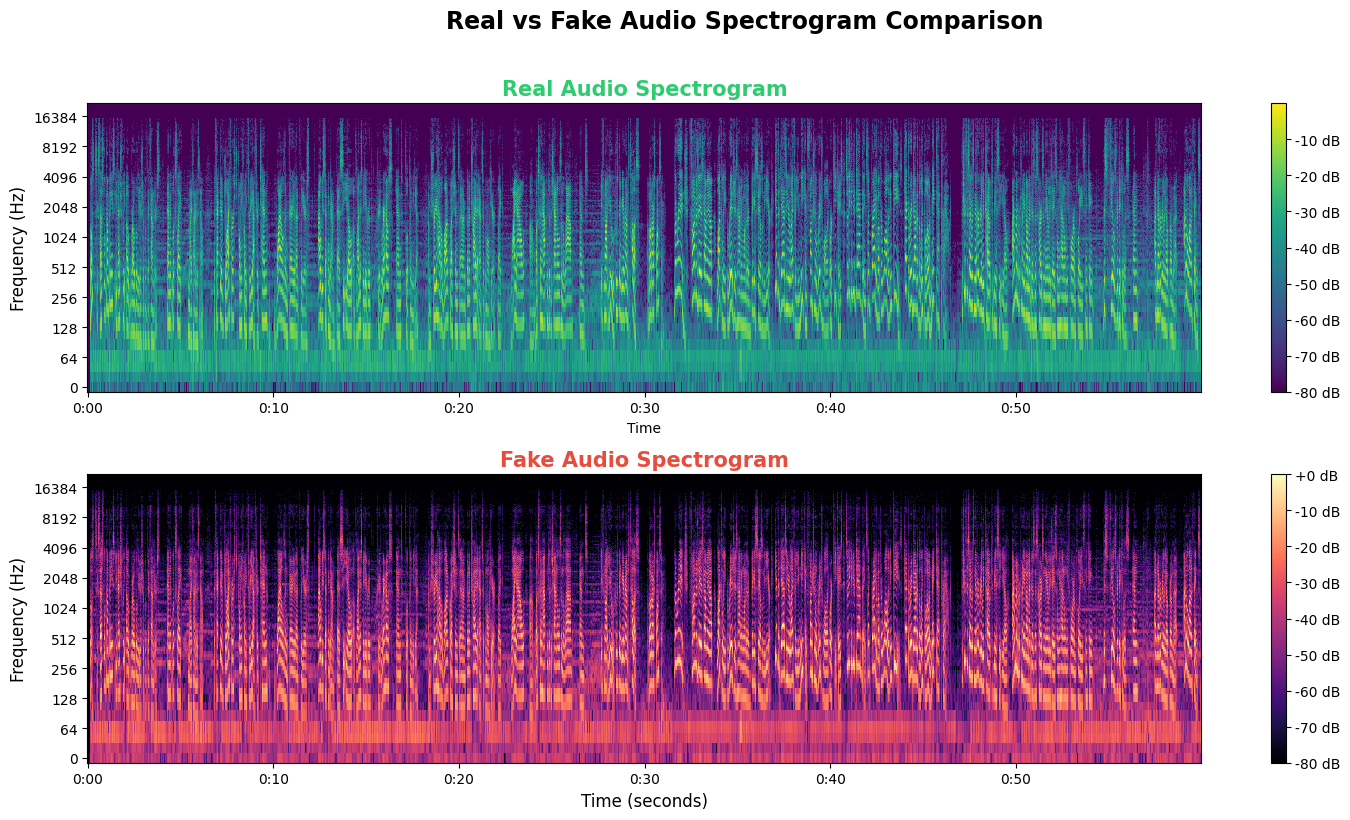

In [11]:
real_spec = np.abs(librosa.stft(real_ad))
real_spec_db = librosa.amplitude_to_db(real_spec, ref=np.max)

fake_spec = np.abs(librosa.stft(fake_ad))
fake_spec_db = librosa.amplitude_to_db(fake_spec, ref=np.max)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
librosa.display.specshow(real_spec_db, sr=real_sr, x_axis="time", y_axis="log", cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("Real Audio Spectrogram", fontsize=15, fontweight='bold', color="#2ecc71")
plt.ylabel("Frequency (Hz)", fontsize=12)
plt.grid(False)

plt.subplot(2, 1, 2)
librosa.display.specshow(fake_spec_db, sr=fake_sr, x_axis="time", y_axis="log", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Fake Audio Spectrogram", fontsize=15, fontweight='bold', color="#e74c3c")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)
plt.grid(False)

plt.suptitle("Real vs Fake Audio Spectrogram Comparison", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

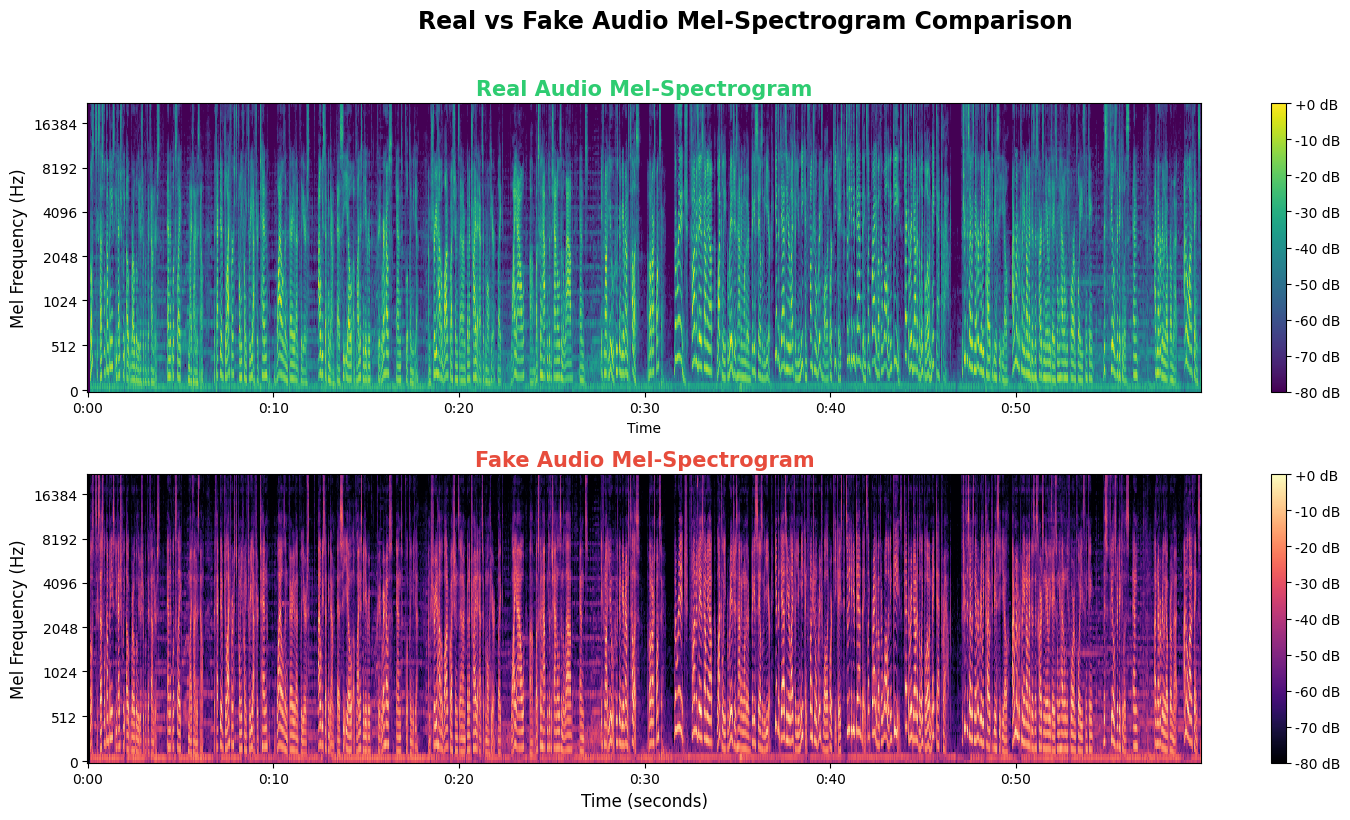

In [12]:
import librosa.display

real_mel = librosa.feature.melspectrogram(y=real_ad, sr=real_sr, n_mels=128, fmax=8000)
real_mel_db = librosa.power_to_db(real_mel, ref=np.max)

fake_mel = librosa.feature.melspectrogram(y=fake_ad, sr=fake_sr, n_mels=128, fmax=8000)
fake_mel_db = librosa.power_to_db(fake_mel, ref=np.max)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
librosa.display.specshow(real_mel_db, sr=real_sr, x_axis="time", y_axis="mel", cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("Real Audio Mel-Spectrogram", fontsize=15, fontweight='bold', color="#2ecc71")
plt.ylabel("Mel Frequency (Hz)", fontsize=12)
plt.grid(False)

plt.subplot(2, 1, 2)
librosa.display.specshow(fake_mel_db, sr=fake_sr, x_axis="time", y_axis="mel", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Fake Audio Mel-Spectrogram", fontsize=15, fontweight='bold', color="#e74c3c")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Mel Frequency (Hz)", fontsize=12)
plt.grid(False)

plt.suptitle("Real vs Fake Audio Mel-Spectrogram Comparison", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


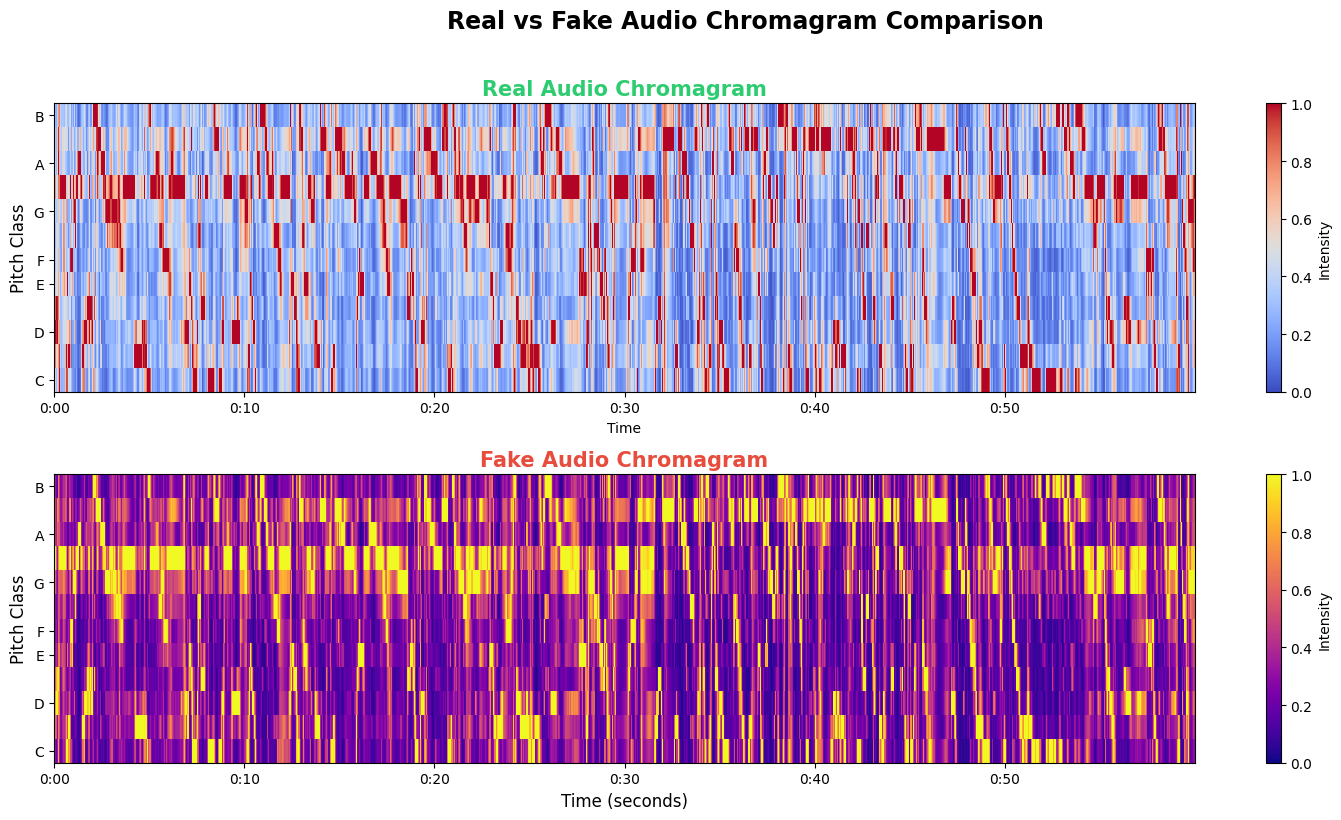

In [13]:
import librosa.display

real_chroma = librosa.feature.chroma_cqt(y=real_ad, sr=real_sr, bins_per_octave=36)
fake_chroma = librosa.feature.chroma_cqt(y=fake_ad, sr=fake_sr, bins_per_octave=36)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
librosa.display.specshow(real_chroma, sr=real_sr, x_axis="time", y_axis="chroma",
                         vmin=0, vmax=1, cmap="coolwarm")
plt.colorbar(label="Intensity")
plt.title("Real Audio Chromagram", fontsize=15, fontweight='bold', color="#2ecc71")
plt.ylabel("Pitch Class", fontsize=12)
plt.grid(False)

plt.subplot(2, 1, 2)
librosa.display.specshow(fake_chroma, sr=fake_sr, x_axis="time", y_axis="chroma",
                         vmin=0, vmax=1, cmap="plasma")
plt.colorbar(label="Intensity")
plt.title("Fake Audio Chromagram", fontsize=15, fontweight='bold', color="#e74c3c")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Pitch Class", fontsize=12)
plt.grid(False)

plt.suptitle("Real vs Fake Audio Chromagram Comparison", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

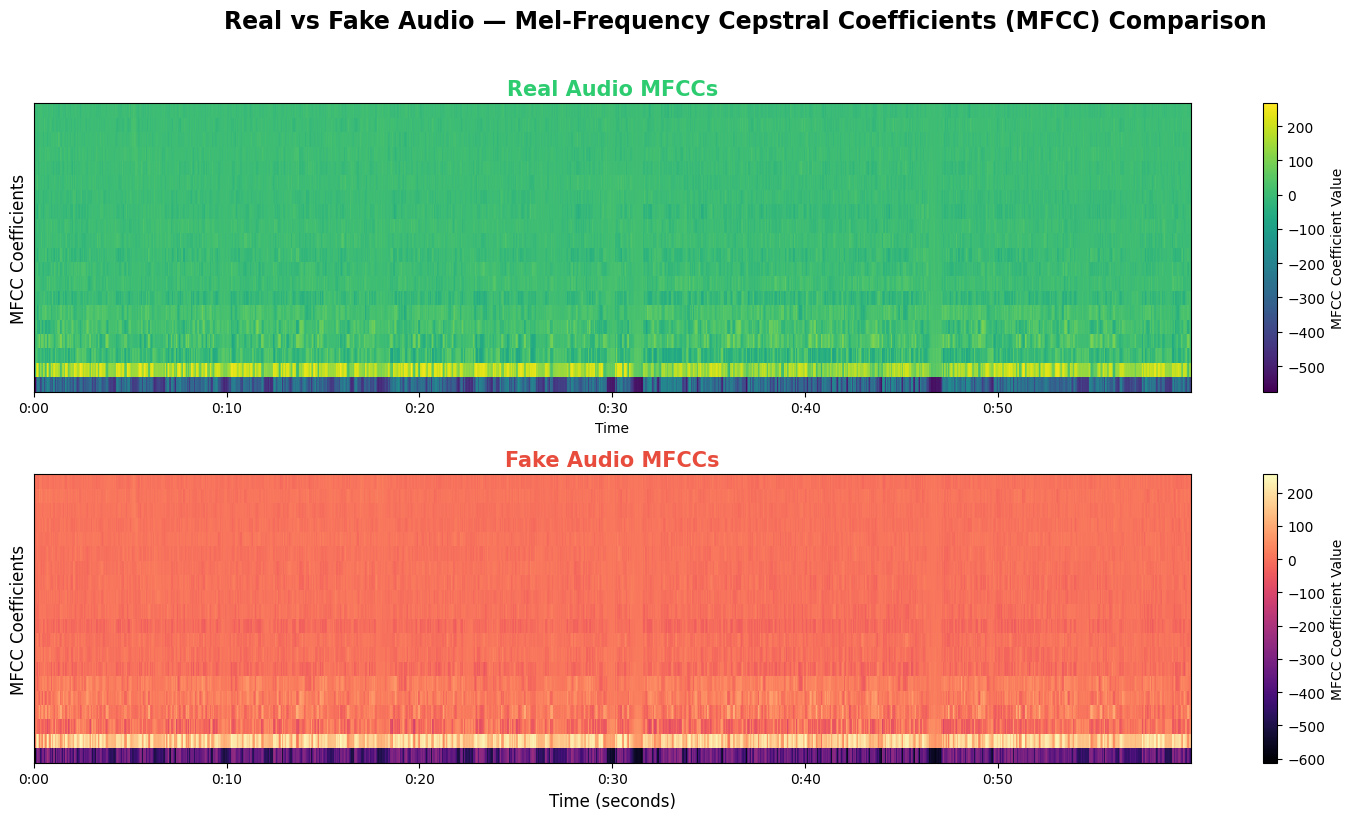

In [14]:
import librosa.display

real_mfccs = librosa.feature.mfcc(y=real_ad, sr=real_sr, n_mfcc=20)
fake_mfccs = librosa.feature.mfcc(y=fake_ad, sr=fake_sr, n_mfcc=20)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
librosa.display.specshow(real_mfccs, sr=real_sr, x_axis="time", cmap="viridis")
plt.colorbar(label="MFCC Coefficient Value")
plt.title("Real Audio MFCCs", fontsize=15, fontweight='bold', color="#2ecc71")
plt.ylabel("MFCC Coefficients", fontsize=12)
plt.grid(False)

plt.subplot(2, 1, 2)
librosa.display.specshow(fake_mfccs, sr=fake_sr, x_axis="time", cmap="magma")
plt.colorbar(label="MFCC Coefficient Value")
plt.title("Fake Audio MFCCs", fontsize=15, fontweight='bold', color="#e74c3c")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("MFCC Coefficients", fontsize=12)
plt.grid(False)

plt.suptitle("Real vs Fake Audio — Mel-Frequency Cepstral Coefficients (MFCC) Comparison",
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Preprocess

In [75]:
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/validation/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/testing/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/training/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-original/for-original/training/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-original/for-original/testing/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-original/for-original/validation/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/training/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/testing/"))
print(os.listdir("/kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/validation/"))

['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']
['fake', 'real']


In [15]:
import os
from tqdm import tqdm

DATASET_PATH = "/kaggle/input/the-fake-or-real-dataset"

SUBFOLDERS = [
    "for-norm/for-norm",
    "for-2sec/for-2seconds",
    "for-original/for-original",
    "for-rerec/for-rerecorded"
]

SPLITS = ["training", "testing", "validation"]

data = []
labels = []

for subfolder in SUBFOLDERS:
    for split in SPLITS:
        split_path = os.path.join(DATASET_PATH, subfolder, split)

        for category in ["fake", "real"]:
            category_path = os.path.join(split_path, category)

            if not os.path.exists(category_path):
                print(f"Skipping missing folder: {category_path}")
                continue

            files = [f for f in os.listdir(category_path) if f.endswith((".wav", ".mp3"))]
            print(f"\nProcessing: {category_path}  ({len(files)} files)")

            for file in tqdm(files, desc=f"{split}/{category}", leave=False):
                file_path = os.path.join(category_path, file)
                try:
                    audio, sr = librosa.load(file_path, res_type="kaiser_fast")

                    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                    delta_mfcc = librosa.feature.delta(mfccs)
                    delta2_mfcc = librosa.feature.delta(mfccs, order=2)

                    features = np.mean(np.vstack([mfccs, delta_mfcc, delta2_mfcc]).T, axis=0)

                    data.append(features)
                    labels.append(category)

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

data = np.array(data)
labels = np.array(labels)

print("\nFeature extraction complete!")
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}") 



Processing: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake  (26927 files)


training/fake:  91%|█████████ | 24567/26927 [11:40<01:09, 34.04it/s]

Error processing /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake/file2846.wav_16k.wav_norm.wav_mono.wav_silence.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=6



Processing: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real  (26941 files)


training/real:   4%|▍         | 1017/26941 [00:48<18:06, 23.86it/s]

...


Processing: /kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/testing/fake  (408 files)



Processing: /kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/testing/real  (408 files)



Processing: /kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/validation/fake  (1143 files)



Processing: /kaggle/input/the-fake-or-real-dataset/for-rerec/for-rerecorded/validation/real  (1101 files)



Feature extraction complete!
Data shape: (169729, 120)
Labels shape: (169729,)
Unique labels: ['fake' 'real']


In [77]:
# import os
# from tqdm import tqdm

# data = []
# labels = []

# for folder in folders:
#     folder_path = os.path.join(audio_files_path, folder)
#     files = [f for f in os.listdir(folder_path) if f.endswith((".wav", ".mp3"))]  
    
#     print(f"Processing folder: {folder} ({len(files)} files)")
    
#     for file in tqdm(files, desc=f"Processing {folder}", leave=False):
#         try:
#             file_path = os.path.join(folder_path, file)
#             audio, sample_rate = librosa.load(file_path, res_type="kaiser_fast")
            
#             mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
            
#             delta_mfcc = librosa.feature.delta(mfccs)
#             delta2_mfcc = librosa.feature.delta(mfccs, order=2)
            
#             combined_features = np.mean(np.vstack([mfccs, delta_mfcc, delta2_mfcc]).T, axis=0)
            
#             data.append(combined_features)
#             labels.append(folder)
        
#         except Exception as e:
#             print(f"Error processing {file_path}: {e}")

# data = np.array(data)
# labels = np.array(labels)

# print(f"\nFeature extraction complete! Data shape: {data.shape}, Labels shape: {labels.shape}")


In [18]:
print(f"Data shape: {data.shape}")   
print(f"Labels shape: {labels.shape}") 

for i in range(5):
    print(f"\nSample {i+1}:")
    print(f"Label: {labels[i]}")
    print(f"Features: {data[i]}")


Data shape: (169729, 120)
Labels shape: (169729,)

Sample 1:
Label: fake
Features: [-2.21929337e+02  1.11129318e+02 -9.40674973e+00  7.02666397e+01
  7.97170579e-01  1.88411484e+01 -1.74676876e+01  2.78700233e+00
 -9.05237007e+00 -8.76006222e+00 -6.75144005e+00 -1.77537098e+01
  6.42462111e+00 -1.12152557e+01  2.64995551e+00 -1.23738441e+01
  1.40562403e+00  4.05178261e+00 -1.16548128e+01  4.45837879e+00
 -3.66869521e+00 -2.38088298e+00 -5.27468634e+00  3.43646914e-01
 -5.40010405e+00 -7.00056329e-02  2.06651998e+00 -3.34247613e+00
  3.70621252e+00 -3.69384885e+00  3.94974887e-01 -2.11408401e+00
  3.42265391e+00  5.98261166e+00  6.63810968e+00  8.50818348e+00
  3.22470570e+00  5.01443100e+00  1.80497420e+00  4.49378681e+00
 -5.83477080e-01  7.47764409e-01 -3.42962831e-01  9.71051380e-02
  1.34117693e-01 -7.36625373e-01  4.46862355e-03 -6.62603676e-01
  4.01685178e-01  4.61632945e-02 -1.80615216e-01  6.13252409e-02
 -1.42122835e-01  5.04149079e-01 -4.25270051e-01 -4.08773273e-01
  1.120

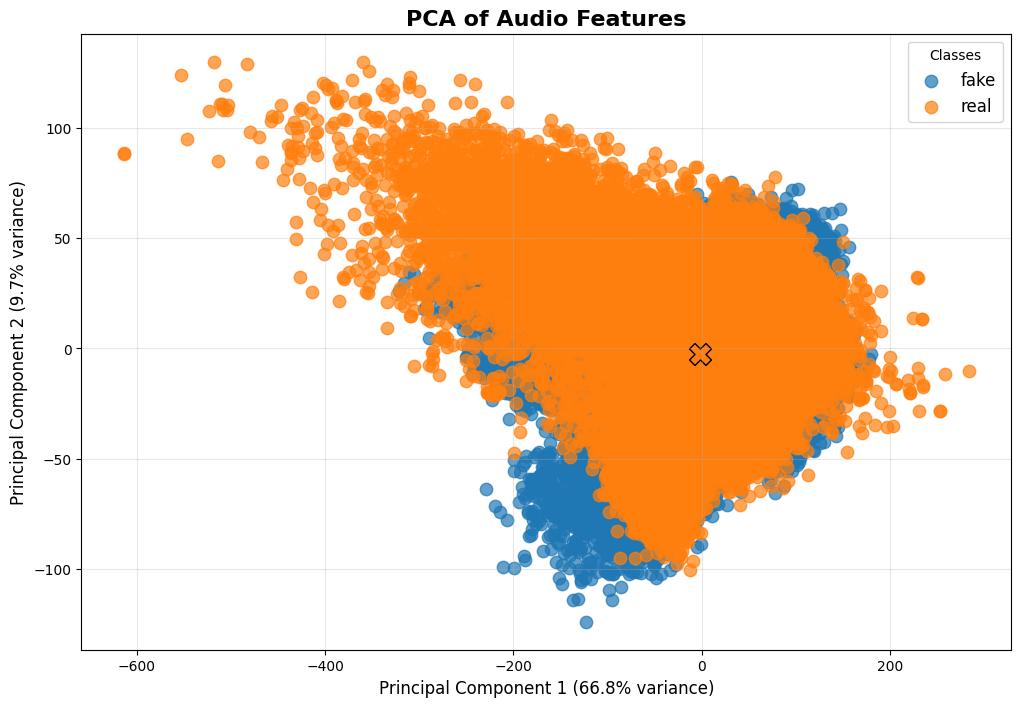

In [19]:
# reducing the features for visualizing 

from sklearn.decomposition import PCA
import seaborn as sns

palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(12, 8))

for i, label in enumerate(np.unique(labels)):
    idx = labels == label
    plt.scatter(
        data_2d[idx, 0], data_2d[idx, 1],
        label=label,
        alpha=0.7,
        s=80,
        color=palette[i]
    )
    
    centroid = data_2d[idx].mean(axis=0)
    plt.scatter(centroid[0], centroid[1], color=palette[i], edgecolor='k', s=250, marker='X')

plt.title("PCA of Audio Features", fontsize=16, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({explained_var[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"Principal Component 2 ({explained_var[1]*100:.1f}% variance)", fontsize=12)
plt.legend(title="Classes", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [20]:
# each column here represt the mfcc feature
num_features = data.shape[1]
feature_columns = [f"mfcc_{i+1}" for i in range(num_features)]

df = pd.DataFrame(data, columns=feature_columns)

df['label'] = labels

print(df.head(10))

       mfcc_1      mfcc_2     mfcc_3     mfcc_4     mfcc_5     mfcc_6  \
0 -221.929337  111.129318  -9.406750  70.266640   0.797171  18.841148   
1 -196.265457  140.971146 -33.391418  68.253609  -5.549876  29.899967   
2 -178.564484  153.188919 -71.684563  34.306919  -9.672385   4.252564   
3 -208.235992  143.761063 -15.328055  58.785648 -10.980986  23.116474   
4 -288.590759  100.461197  -5.685215  61.663986  -8.509184 -33.828335   
5 -252.915482  152.607880 -16.524874   8.870251 -14.682841 -25.917313   
6 -229.997559  154.292892 -21.877245  56.846947 -11.411739  14.785260   
7 -212.967468  167.318253  -9.927441  59.897190   6.904475 -24.110598   
8 -174.585251  132.256027 -44.834736  26.076319 -33.357063  10.172033   
9 -259.361786  157.049927  -9.230187   5.019715 -17.633963 -15.130705   

      mfcc_7     mfcc_8     mfcc_9    mfcc_10  ...  mfcc_112  mfcc_113  \
0 -17.467688   2.787002  -9.052370  -8.760062  ...  0.212538  0.018125   
1 -21.325544   6.374795  -3.532048  -5.227132  .

In [21]:
df['label'].value_counts()

label
fake    84979
real    84750
Name: count, dtype: int64

In [22]:
df

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_112,mfcc_113,mfcc_114,mfcc_115,mfcc_116,mfcc_117,mfcc_118,mfcc_119,mfcc_120,label
0,-221.929337,111.129318,-9.406750,70.266640,0.797171,18.841148,-17.467688,2.787002,-9.052370,-8.760062,...,0.212538,0.018125,-0.092293,-0.283686,-0.498475,-0.385444,-0.187428,0.305859,0.292604,fake
1,-196.265457,140.971146,-33.391418,68.253609,-5.549876,29.899967,-21.325544,6.374795,-3.532048,-5.227132,...,-0.007324,-0.001140,0.035587,0.063372,-0.067645,0.030032,-0.003701,-0.022435,0.059315,fake
2,-178.564484,153.188919,-71.684563,34.306919,-9.672385,4.252564,-16.709230,-10.407344,-28.526506,-10.249151,...,0.004159,-0.353531,-0.431514,-0.430520,-0.282879,0.042415,0.188623,0.296430,0.175613,fake
3,-208.235992,143.761063,-15.328055,58.785648,-10.980986,23.116474,-13.376741,3.987922,-9.350453,-4.579097,...,0.024811,-0.052374,-0.000773,0.020830,-0.044879,0.054573,-0.008311,0.039182,0.005403,fake
4,-288.590759,100.461197,-5.685215,61.663986,-8.509184,-33.828335,-17.348455,-26.891876,-26.251787,-15.632066,...,0.024465,0.037296,-0.024378,-0.051487,-0.040435,-0.004741,0.014531,-0.001554,-0.033295,fake
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169724,-185.517914,139.755615,-10.072881,49.143349,-22.174185,11.238420,-1.988563,-8.680297,-5.926900,-20.661800,...,-0.016889,0.053861,-0.053004,-0.070958,0.005752,-0.100622,-0.070173,0.016353,-0.004643,real
169725,-184.952805,160.139664,10.816940,38.920872,-28.797812,31.615793,-6.011405,-13.334786,-4.156356,-23.379557,...,0.083937,0.073774,-0.049486,-0.006203,0.028123,-0.009781,0.005977,-0.017628,-0.010235,real
169726,-234.276901,151.887497,22.527786,39.074551,-6.239390,22.157221,-4.745480,-15.529646,-10.115043,-21.771809,...,0.003413,0.085824,0.080700,0.086025,0.059606,0.016712,0.000150,-0.056065,-0.097624,real
169727,-180.439377,154.762573,8.503108,32.731182,-11.573515,22.155344,-16.418337,-8.678101,-7.700779,-20.132877,...,-0.058452,0.018801,-0.032355,0.066910,0.013264,-0.004152,0.059756,0.066623,0.040323,real


In [23]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
df_shuffled

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_112,mfcc_113,mfcc_114,mfcc_115,mfcc_116,mfcc_117,mfcc_118,mfcc_119,mfcc_120,label
0,-179.122009,131.483002,-45.580772,42.248070,-22.874889,10.026948,-11.185899,-5.997731,-22.135342,-12.766664,...,0.019969,0.047059,0.057713,-0.036991,0.041322,0.057714,-0.008747,0.019165,0.004529,fake
1,-344.331482,55.961296,-15.820481,45.356319,-37.968700,-17.403906,-32.928616,-20.688944,-9.395030,-9.223181,...,-0.106227,-0.117895,-0.016175,-0.033213,-0.043026,-0.015149,-0.005871,0.001529,0.020677,fake
2,-213.763626,102.423927,22.679991,41.941711,-35.645832,15.986805,-40.159672,-12.987401,-0.295534,-23.050766,...,0.153663,0.089906,0.118263,0.155627,0.030401,0.112375,0.026575,0.013745,-0.073017,real
3,-431.077332,60.789516,-21.783777,34.907749,-6.950395,3.114065,-8.846411,-6.732517,-6.885506,-12.796541,...,0.010174,0.011263,0.010979,0.009722,0.007917,0.005665,0.002850,-0.000322,-0.003092,fake
4,-221.139328,88.268234,-11.443578,73.510155,-9.118316,4.230177,-9.735612,4.371761,-5.181702,-10.481799,...,0.056663,0.076214,0.068006,0.080980,0.066560,-0.019879,-0.175616,-0.247143,-0.260662,real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169724,-313.972076,96.224091,-11.763568,19.259121,-12.559515,-21.732347,-15.036362,-25.417313,-16.240728,-0.378412,...,-0.006235,-0.016383,0.014652,0.024886,0.020013,-0.012413,0.003260,0.027906,0.012091,real
169725,-350.562134,55.946217,14.043468,20.331900,-21.762716,-17.987173,-19.661102,-25.262058,-23.168886,-8.596224,...,-0.301634,-0.259614,-0.139768,0.093893,0.097810,0.081651,-0.020892,-0.066878,-0.003154,fake
169726,-255.409012,134.422211,-27.881645,60.361126,-11.979138,28.650150,-12.641389,0.051392,-11.047113,-8.067270,...,-0.007425,-0.004685,-0.011502,-0.003706,-0.005995,0.001206,0.008149,-0.006847,0.004155,real
169727,-309.156830,105.505760,3.201860,3.258861,-35.559570,-23.793354,-9.683268,-34.983505,-20.913502,-0.137161,...,-0.169641,-0.037515,0.050254,0.090120,0.009547,-0.025720,-0.016026,0.021066,0.077271,fake


# Enhanced Data Exploration and Visualization
Let's start by visualizing the distribution of MFCC features and the class balance. This helps us understand the data before modeling.

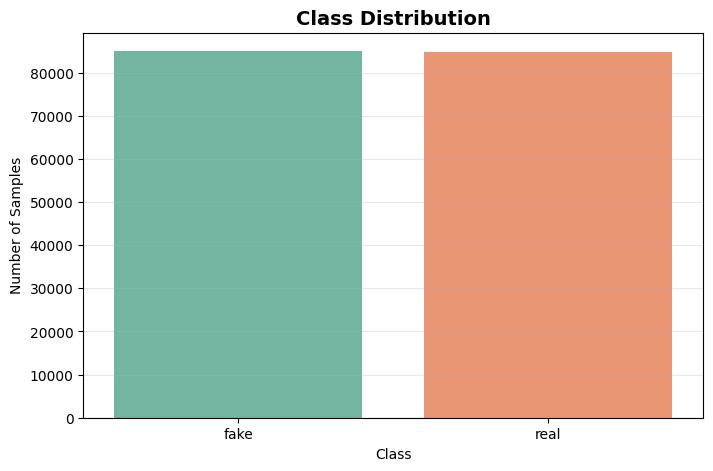

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_shuffled, x='label', palette="Set2")
plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(alpha=0.3, axis='y')
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


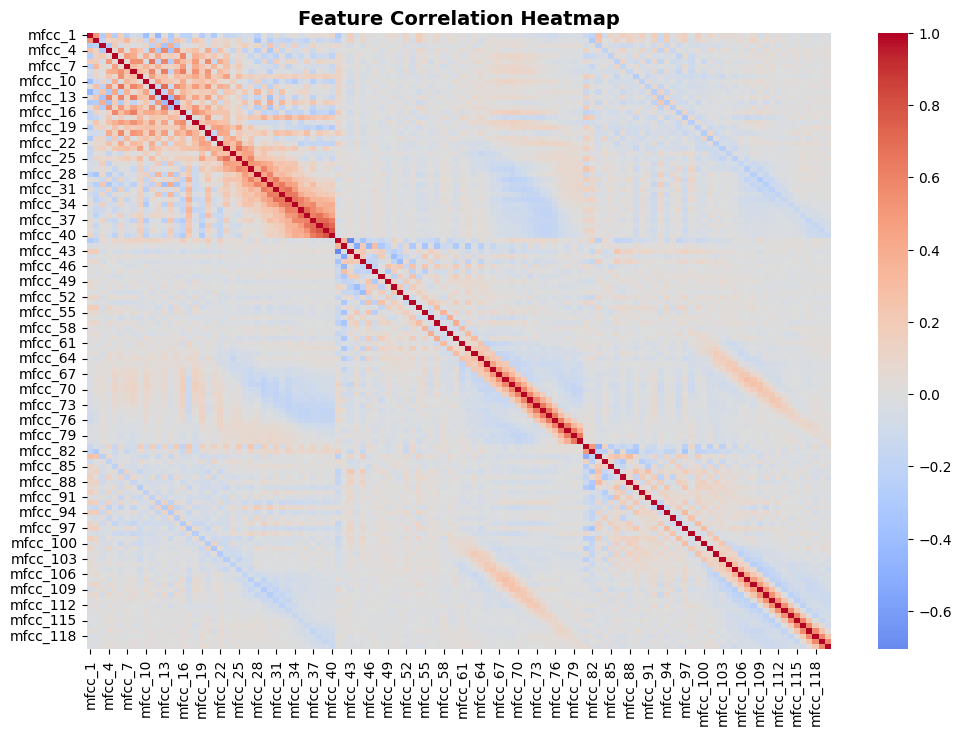

In [26]:
# heatmap for feature corelation 

plt.figure(figsize=(12, 8))
sns.heatmap(df_shuffled.drop('label', axis=1).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

In [27]:
unique_labels = df_shuffled['label'].unique()
unique_labels

array(['fake', 'real'], dtype=object)

In [28]:
label_mapping = {label: idx for idx, label in enumerate(unique_labels)}

df_shuffled['label'] = df_shuffled['label'].replace(label_mapping)

/tmp/ipykernel_301/4014852104.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_shuffled['label'] = df_shuffled['label'].replace(label_mapping)


In [29]:
df_shuffled

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_112,mfcc_113,mfcc_114,mfcc_115,mfcc_116,mfcc_117,mfcc_118,mfcc_119,mfcc_120,label
0,-179.122009,131.483002,-45.580772,42.248070,-22.874889,10.026948,-11.185899,-5.997731,-22.135342,-12.766664,...,0.019969,0.047059,0.057713,-0.036991,0.041322,0.057714,-0.008747,0.019165,0.004529,0
1,-344.331482,55.961296,-15.820481,45.356319,-37.968700,-17.403906,-32.928616,-20.688944,-9.395030,-9.223181,...,-0.106227,-0.117895,-0.016175,-0.033213,-0.043026,-0.015149,-0.005871,0.001529,0.020677,0
2,-213.763626,102.423927,22.679991,41.941711,-35.645832,15.986805,-40.159672,-12.987401,-0.295534,-23.050766,...,0.153663,0.089906,0.118263,0.155627,0.030401,0.112375,0.026575,0.013745,-0.073017,1
3,-431.077332,60.789516,-21.783777,34.907749,-6.950395,3.114065,-8.846411,-6.732517,-6.885506,-12.796541,...,0.010174,0.011263,0.010979,0.009722,0.007917,0.005665,0.002850,-0.000322,-0.003092,0
4,-221.139328,88.268234,-11.443578,73.510155,-9.118316,4.230177,-9.735612,4.371761,-5.181702,-10.481799,...,0.056663,0.076214,0.068006,0.080980,0.066560,-0.019879,-0.175616,-0.247143,-0.260662,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169724,-313.972076,96.224091,-11.763568,19.259121,-12.559515,-21.732347,-15.036362,-25.417313,-16.240728,-0.378412,...,-0.006235,-0.016383,0.014652,0.024886,0.020013,-0.012413,0.003260,0.027906,0.012091,1
169725,-350.562134,55.946217,14.043468,20.331900,-21.762716,-17.987173,-19.661102,-25.262058,-23.168886,-8.596224,...,-0.301634,-0.259614,-0.139768,0.093893,0.097810,0.081651,-0.020892,-0.066878,-0.003154,0
169726,-255.409012,134.422211,-27.881645,60.361126,-11.979138,28.650150,-12.641389,0.051392,-11.047113,-8.067270,...,-0.007425,-0.004685,-0.011502,-0.003706,-0.005995,0.001206,0.008149,-0.006847,0.004155,1
169727,-309.156830,105.505760,3.201860,3.258861,-35.559570,-23.793354,-9.683268,-34.983505,-20.913502,-0.137161,...,-0.169641,-0.037515,0.050254,0.090120,0.009547,-0.025720,-0.016026,0.021066,0.077271,0


# Feature Scaling

In [30]:
import numpy as np

X = df_shuffled.drop('label', axis=1).values

y = df_shuffled['label'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (169729, 120)
y shape: (169729,)


In [31]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [32]:
y_resampled = to_categorical(y_resampled)

In [33]:
y_resampled

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [35]:
num_labels = len(df_shuffled["label"].unique())
num_labels

2

In [36]:
input_shape = X[0].shape
input_shape

(120,)

# Machine Learning Model Comparison
We will train and compare several models:
- Random Forest
- Support Vector Machine (SVM)
- LogisticRegression
- KNeighboursClassifier
- xgb

We will use accuracy, confusion matrix, and classification report for evaluation.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [38]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

if y_resampled.ndim > 1:
    y_resampled_ml = np.argmax(y_resampled, axis=1)
else:
    y_resampled_ml = y_resampled

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_resampled, y_resampled_ml, test_size=0.2, random_state=42, stratify=y_resampled_ml
)

In [40]:
scale_models = ["SVM", "Logistic Regression", "KNN"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_test_scaled = scaler.transform(X_test_ml)

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

def train_evaluate(model, model_name, X_train, X_test, y_train, y_test, batch_size=32, epochs=5):
    is_keras = "tensorflow" in str(type(model)).lower()
    
    if is_keras:
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            batch_size=batch_size,
            epochs=epochs,
            verbose=1
        )
        y_pred_probs = model.predict(X_test)
        
        if y_test.ndim > 1 and y_test.shape[1] > 1:
            y_test_labels = np.argmax(y_test, axis=1)
            y_pred_labels = np.argmax(y_pred_probs, axis=1)
        else:
            y_test_labels = y_test
            y_pred_labels = y_pred_probs
    else:
        model.fit(X_train, y_train)
        y_pred_labels = model.predict(X_test)
        y_test_labels = y_test
        history = None
    
    acc = accuracy_score(y_test_labels, y_pred_labels)
    precision = precision_score(y_test_labels, y_pred_labels, average='weighted')
    recall = recall_score(y_test_labels, y_pred_labels, average='weighted')
    f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')
    
    cm = confusion_matrix(y_test_labels, y_pred_labels)
    cr = classification_report(y_test_labels, y_pred_labels)
    
    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:\n", cr)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return acc, precision, recall, f1, cm, cr, y_pred_labels, history


Training and evaluating: Random Forest

===== Random Forest =====
Accuracy : 0.9815
Precision: 0.9817
Recall   : 0.9815
F1-score : 0.9815

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     16996
           1       0.99      0.97      0.98     16996

    accuracy                           0.98     33992
   macro avg       0.98      0.98      0.98     33992
weighted avg       0.98      0.98      0.98     33992



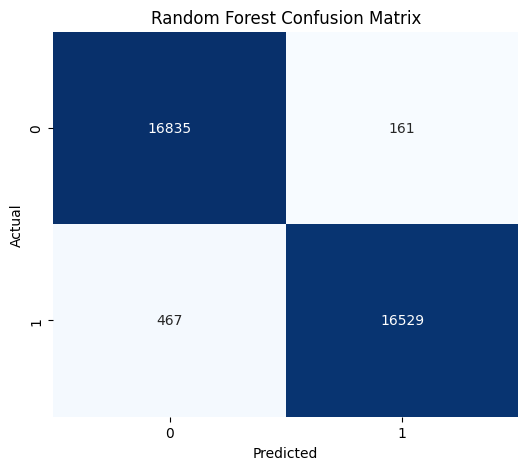


Training and evaluating: SVM

===== SVM =====
Accuracy : 0.9916
Precision: 0.9916
Recall   : 0.9916
F1-score : 0.9916

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     16996
           1       1.00      0.99      0.99     16996

    accuracy                           0.99     33992
   macro avg       0.99      0.99      0.99     33992
weighted avg       0.99      0.99      0.99     33992



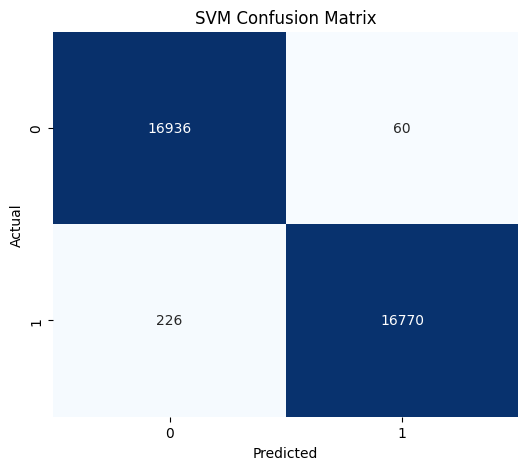


Training and evaluating: Logistic Regression

===== Logistic Regression =====
Accuracy : 0.8825
Precision: 0.8825
Recall   : 0.8825
F1-score : 0.8825

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88     16996
           1       0.89      0.88      0.88     16996

    accuracy                           0.88     33992
   macro avg       0.88      0.88      0.88     33992
weighted avg       0.88      0.88      0.88     33992



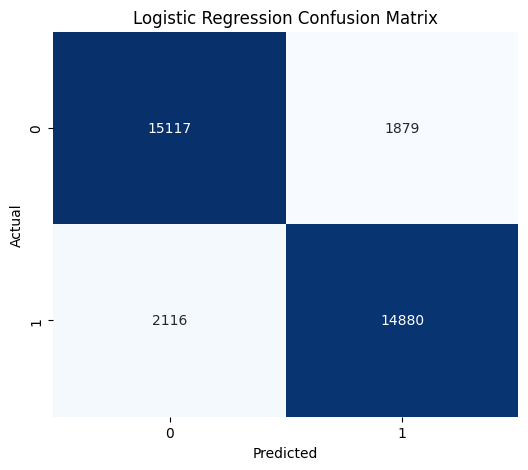


Training and evaluating: KNN

===== KNN =====
Accuracy : 0.9837
Precision: 0.9837
Recall   : 0.9837
F1-score : 0.9837

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     16996
           1       0.98      0.99      0.98     16996

    accuracy                           0.98     33992
   macro avg       0.98      0.98      0.98     33992
weighted avg       0.98      0.98      0.98     33992



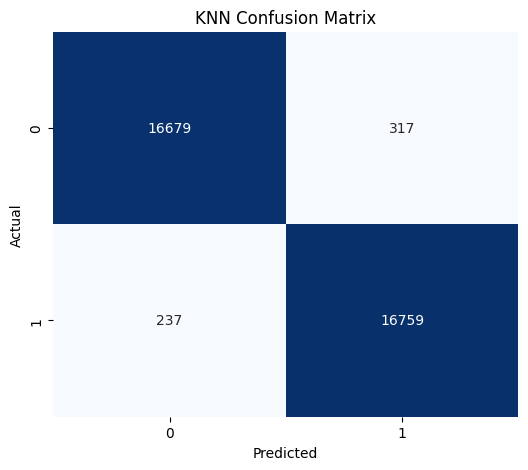


Training and evaluating: XGBoost

===== XGBoost =====
Accuracy : 0.9931
Precision: 0.9931
Recall   : 0.9931
F1-score : 0.9931

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     16996
           1       0.99      0.99      0.99     16996

    accuracy                           0.99     33992
   macro avg       0.99      0.99      0.99     33992
weighted avg       0.99      0.99      0.99     33992



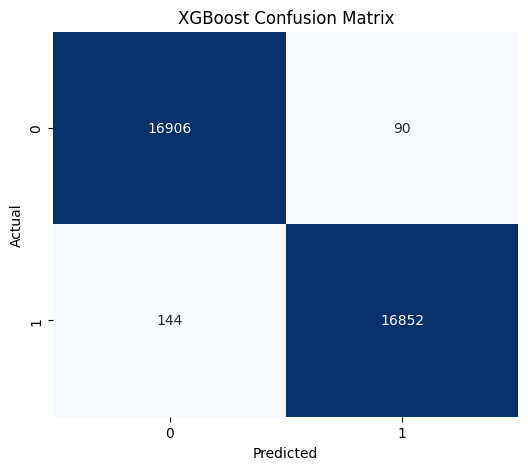


===== Model Performance Summary =====


,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost,0.993116,0.993121,0.993116,0.993116
1,SVM,0.991586,0.991633,0.991586,0.991586
3,KNN,0.983702,0.983713,0.983702,0.983702
0,Random Forest,0.981525,0.981681,0.981525,0.981524
2,Logistic Regression,0.882472,0.882547,0.882472,0.882467


In [58]:
results = {}

for name, model in models.items():
    print(f"\nTraining and evaluating: {name}")
    
    if name in scale_models:
        acc, precision, recall, f1, cm, cr, y_pred, history = train_evaluate(
            model, name, X_train_scaled, X_test_scaled, y_train_ml, y_test_ml
        )
    else:
        acc, precision, recall, f1, cm, cr, y_pred, history = train_evaluate(
            model, name, X_train_ml, X_test_ml, y_train_ml, y_test_ml
        )

    results[name] = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm,
        "classification_report": cr,
        "y_pred": y_pred,
        "history": history
    }

import pandas as pd

summary_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-Score": res["f1_score"]
    }
    for name, res in results.items()
])

print("\n===== Model Performance Summary =====")
display(summary_df.sort_values(by="Accuracy", ascending=False))

# Model Comparison Summary
Below is a summary table comparing the accuracy of all models. The best model will be recommended based on accuracy and classification report.

===== Model Performance Summary =====


,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.993116,0.993121,0.993116,0.993116
1,SVM,0.991586,0.991633,0.991586,0.991586
2,KNN,0.983702,0.983713,0.983702,0.983702
3,Random Forest,0.981525,0.981681,0.981525,0.981524
4,Logistic Regression,0.882472,0.882547,0.882472,0.882467


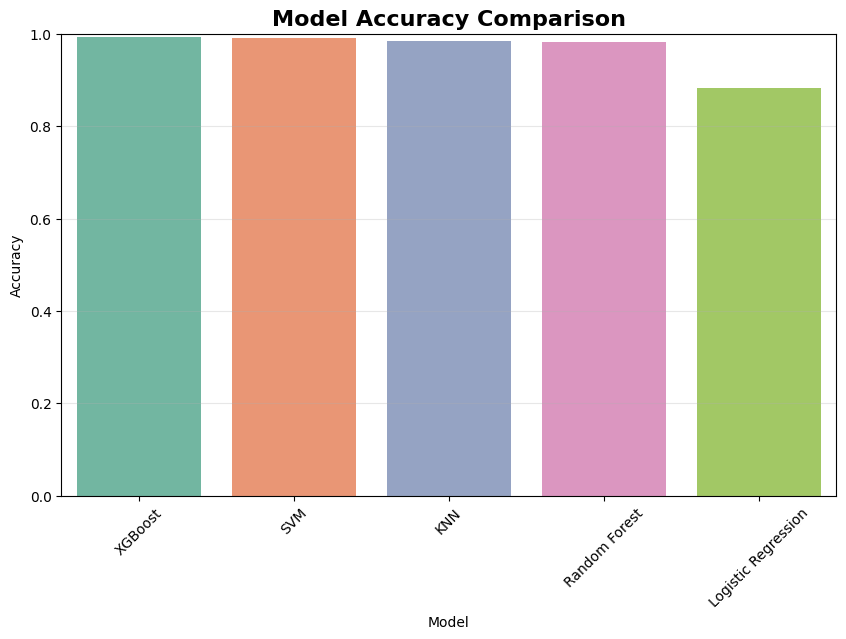

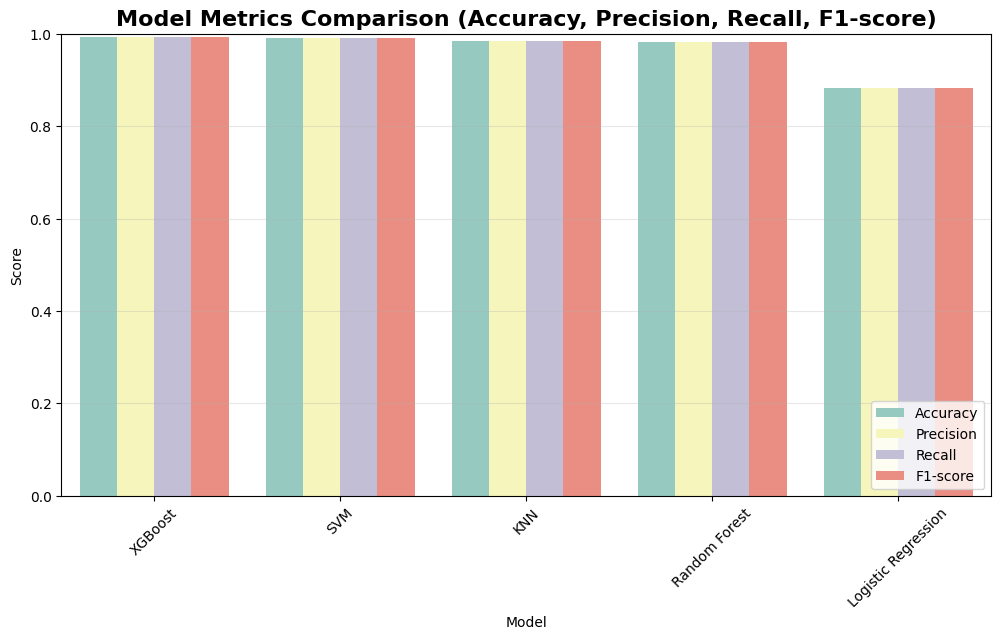

In [59]:
from sklearn.metrics import precision_recall_fscore_support

summary_data = []

for name, res in results.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_ml, res['y_pred'], average='weighted')
    summary_data.append({
        "Model": name,
        "Accuracy": res['accuracy'],
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("===== Model Performance Summary =====")
display(summary_df)

plt.figure(figsize=(10,6))
sns.barplot(data=summary_df, x="Model", y="Accuracy", palette="Set2")
plt.ylim(0,1)
plt.title("Model Accuracy Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.show()

summary_df_melted = summary_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
                                    var_name="Metric", value_name="Value")

plt.figure(figsize=(12,6))
sns.barplot(data=summary_df_melted, x="Model", y="Value", hue="Metric", palette="Set3")
plt.ylim(0,1)
plt.title("Model Metrics Comparison (Accuracy, Precision, Recall, F1-score)", fontsize=16, fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(alpha=0.3, axis='y')
plt.show()

# Deep Learning Model: 

### Basic deep learning model 

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.initializers import HeNormal

model = Sequential()

model.add(Dense(512, input_shape=input_shape, kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(1024, kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(512, kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(256, kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(num_labels, activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

model.summary()

model.compile(
    loss="categorical_crossentropy", 
    optimizer="adam", 
    metrics=["accuracy"]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │        61,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253,122 (4.78 MB)

 Trainable params: 1,248,514 (4.76 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [45]:
# withour scaled 

history_without_scaled = model.fit(
    X_train,          
    y_train,                
    validation_split=0.2,    
    epochs=50,              
    batch_size=32,           
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
3400/3400 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9925 - loss: 0.0208
Epoch 1: val_loss improved from 0.00973 to 0.00941, saving model to best_model.h5
3400/3400 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9925 - loss: 0.0208 - val_accuracy: 0.9976 - val_loss: 0.0094
Epoch 2/50
3397/3400 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9936 - loss: 0.0190
Epoch 2: val_loss did not improve from 0.00941
3400/3400 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9936 - loss: 0.0190 - val_accuracy: 0.9970 - val_loss: 0.0095
Epoch 3/50
3389/3400 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9941 - loss: 0.0176
Epoch 3: val_loss did not improve from 0.00941
3400/3400 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9941 - loss: 0.0176 - val_accuracy: 0.9976 - val_loss: 0.0103
Epoch 4/50
3396/3400 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0171
Epoch 4: val_loss did not improve from 0.00941
3400/3400 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9943 - 

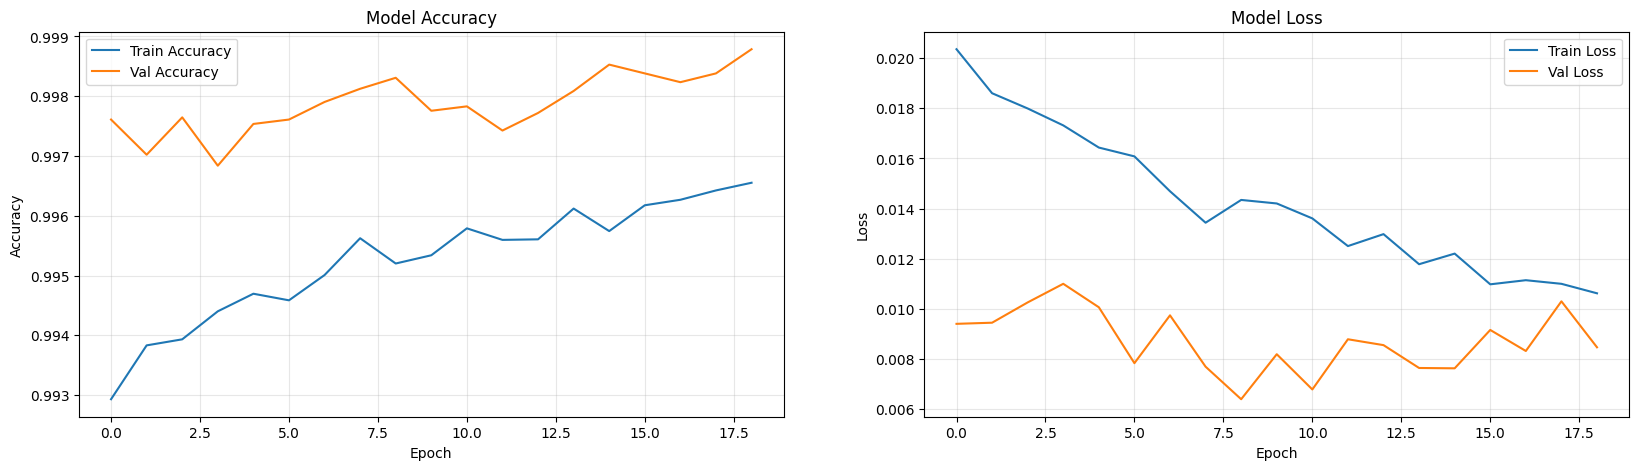

In [48]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history_without_scaled.history['accuracy'], label='Train Accuracy')
plt.plot(history_without_scaled.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_without_scaled.history['loss'], label='Train Loss')
plt.plot(history_without_scaled.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Neural Network Accuracy : 0.9976
Neural Network Precision: 0.9976
Neural Network Recall   : 0.9976
Neural Network F1-Score : 0.9976

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     16920
           1       1.00      1.00      1.00     17072

    accuracy                           1.00     33992
   macro avg       1.00      1.00      1.00     33992
weighted avg       1.00      1.00      1.00     33992



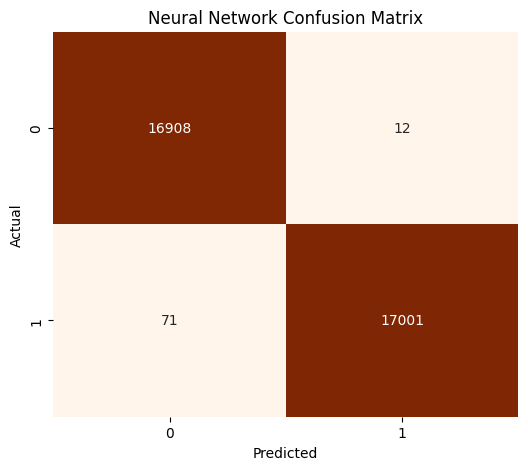

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

nn_pred_probs = model.predict(X_test)
nn_pred = np.argmax(nn_pred_probs, axis=1)
nn_true = np.argmax(y_test, axis=1)

nn_acc_without_scaled = accuracy_score(nn_true, nn_pred)
nn_precision_without_scaled = precision_score(nn_true, nn_pred, average='weighted')
nn_recall_without_scaled = recall_score(nn_true, nn_pred, average='weighted')
nn_f1_without_scaled = f1_score(nn_true, nn_pred, average='weighted')
nn_cm_without_scaled = confusion_matrix(nn_true, nn_pred)
nn_cr_without_scaled = classification_report(nn_true, nn_pred)

print(f"Neural Network Accuracy : {nn_acc_without_scaled:.4f}")
print(f"Neural Network Precision: {nn_precision_without_scaled:.4f}")
print(f"Neural Network Recall   : {nn_recall_without_scaled:.4f}")
print(f"Neural Network F1-Score : {nn_f1_without_scaled:.4f}")
print("\nClassification Report:\n", nn_cr_without_scaled)

plt.figure(figsize=(6,5))
sns.heatmap(nn_cm_without_scaled, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Deep Learning Model: Enhanced Architecture (CNN)
We will now build a deeper neural network with more layers and regularization to improve performance.

In [7]:
import librosa

def extract_mel_spectrogram(file_path, n_mels=128, max_len=128):
    y, sr = librosa.load(file_path, sr=None)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
    
    return mel_db

In [8]:
import os
from tqdm import tqdm

BASE_PATH = "/kaggle/input/the-fake-or-real-dataset/"

DATASETS = {
    # "for-norm": "for-norm",
    "for-2sec": "for-2seconds",
    "for-original": "for-original",
    "for-rerec": "for-rerecorded"
}

SPLITS = ["training", "testing", "validation"]

X_cnn, y_cnn = [], []

for dataset_type, internal_folder in DATASETS.items():
    for split in SPLITS:
        audio_files_path = os.path.join(BASE_PATH, dataset_type, internal_folder, split)
        if not os.path.exists(audio_files_path):
            print(f"Path does not exist: {audio_files_path}")
            continue
        
        folders = os.listdir(audio_files_path)
        print(f"\nLoading {dataset_type}/{split} — Found folders: {folders}")

        for label, folder in enumerate(folders):
            folder_path = os.path.join(audio_files_path, folder)
            files = os.listdir(folder_path)
            print(f"Processing folder: {folder} ({len(files)} files)")

            for file in tqdm(files, desc=f"{dataset_type}/{split}/{folder}"):
                file_path = os.path.join(folder_path, file)
                try:
                    mel = extract_mel_spectrogram(file_path)
                    X_cnn.append(mel)
                    y_cnn.append(label)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

X_cnn = np.array(X_cnn)[..., np.newaxis]
y_cnn = np.array(y_cnn)

print(f"\nLoaded total {len(X_cnn)} samples from all datasets and splits")
print(f"X_cnn shape: {X_cnn.shape}, y_cnn shape: {y_cnn.shape}")



Loading for-2sec/training — Found folders: ['fake', 'real']
Processing folder: fake (6978 files)


for-2sec/training/fake: 100%|██████████| 6978/6978 [02:05<00:00, 55.67it/s]


Processing folder: real (6978 files)


for-2sec/training/real: 100%|██████████| 6978/6978 [01:59<00:00, 58.43it/s]



Loading for-2sec/testing — Found folders: ['fake', 'real']
Processing folder: fake (544 files)


...


Loading for-rerec/validation — Found folders: ['fake', 'real']
Processing folder: fake (1143 files)


for-rerec/validation/fake: 100%|██████████| 1143/1143 [00:20<00:00, 57.02it/s]


Processing folder: real (1101 files)


for-rerec/validation/real: 100%|██████████| 1101/1101 [00:19<00:00, 55.64it/s]



Loaded total 100438 samples from all datasets and splits
X_cnn shape: (100438, 128, 128, 1), y_cnn shape: (100438,)


In [7]:
# X_cnn = []
# y_cnn = []

# for label, folder in enumerate(folders):  
#     files = os.listdir(os.path.join(audio_files_path, folder))
#     for file in tqdm(files):
#         file_path = os.path.join(audio_files_path, folder, file)
#         mel = extract_mel_spectrogram(file_path)
#         X_cnn.append(mel)
#         y_cnn.append(label)

# X_cnn = np.array(X_cnn)
# y_cnn = np.array(y_cnn)

# X_cnn = X_cnn[..., np.newaxis]


In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y_cnn, num_classes=2)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cat, test_size=0.2, random_state=42, stratify=y_cnn
)

In [10]:
num_labels = 2

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

input_shape_cnn = X_train_cnn.shape[1:] 

model_cnn = Sequential()

model_cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape_cnn, padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Dropout(0.2))

model_cnn.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Dropout(0.2))

model_cnn.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Dropout(0.3))

model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.3))
model_cnn.add(Dense(num_labels, activation='softmax'))

model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760281322.044609     301 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760281322.046959     301 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,258 (16.36 MB)

 Trainable params: 4,287,810 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_cnn_model2.h5', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = model_cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/20


I0000 00:00:1760281349.513236     377 service.cc:148] XLA service 0x7bf940002ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760281349.515398     377 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760281349.515420     377 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760281350.107738     377 cuda_dnn.cc:529] Loaded cuDNN version 90300


   5/2009 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.6095 - loss: 10.7554 

I0000 00:00:1760281356.562649     377 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2009/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8601 - loss: 0.5070
Epoch 1: val_loss improved from inf to 2.85607, saving model to best_cnn_model2.h5
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step - accuracy: 0.8602 - loss: 0.5068 - val_accuracy: 0.7643 - val_loss: 2.8561 - learning_rate: 0.0010
Epoch 2/20
2008/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9776 - loss: 0.0574
Epoch 2: val_loss improved from 2.85607 to 0.14955, saving model to best_cnn_model2.h5
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9776 - loss: 0.0574 - val_accuracy: 0.9562 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 3/20
2008/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9836 - loss: 0.0417
Epoch 3: val_loss improved from 0.14955 to 0.05329, saving model to best_cnn_model2.h5
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9836 - loss: 0.0417 - val_accuracy: 0.9798 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 4/20
2008/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/st

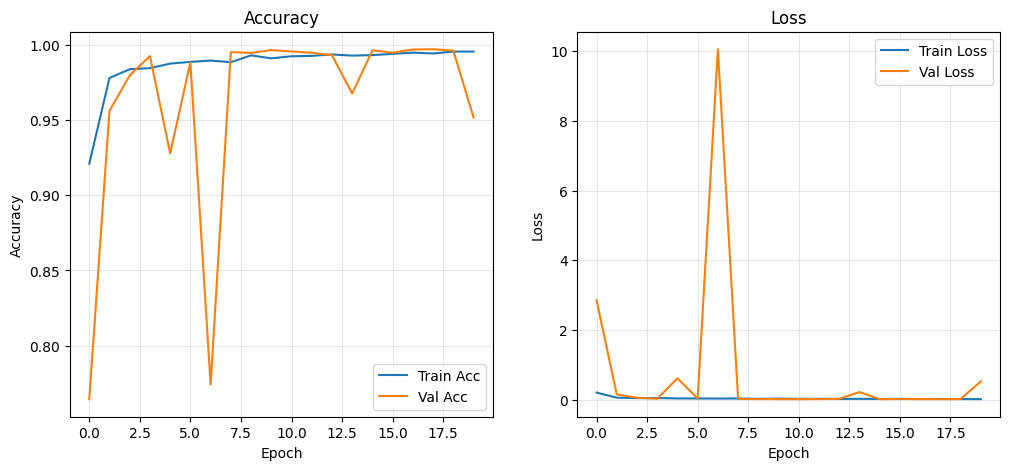

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


628/628 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

===== Neural Network Performance =====
Accuracy : 0.9520
Precision: 0.9562
Recall   : 0.9520
F1-Score : 0.9519

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95     10057
           1       0.91      1.00      0.95     10031

    accuracy                           0.95     20088
   macro avg       0.96      0.95      0.95     20088
weighted avg       0.96      0.95      0.95     20088



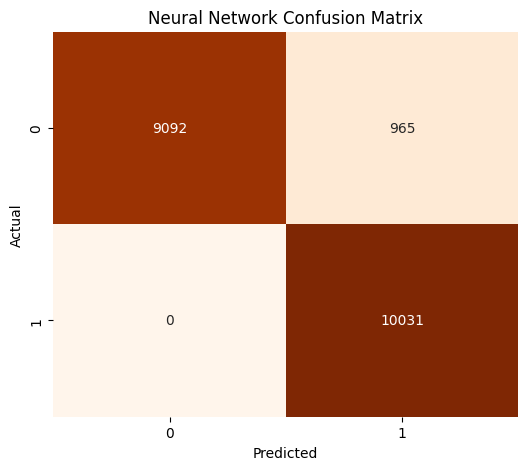

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nn_pred_probs = model_cnn.predict(X_test_cnn)
nn_pred = np.argmax(nn_pred_probs, axis=1)
nn_true = np.argmax(y_test_cnn, axis=1)

nn_acc_cnn = accuracy_score(nn_true, nn_pred)
nn_precision_cnn = precision_score(nn_true, nn_pred, average='weighted')
nn_recall_cnn = recall_score(nn_true, nn_pred, average='weighted')
nn_f1_cnn = f1_score(nn_true, nn_pred, average='weighted')
nn_cm_cnn = confusion_matrix(nn_true, nn_pred)
nn_cr_cnn = classification_report(nn_true, nn_pred)

print(f"\n===== Neural Network Performance =====")
print(f"Accuracy : {nn_acc_cnn:.4f}")
print(f"Precision: {nn_precision_cnn:.4f}")
print(f"Recall   : {nn_recall_cnn:.4f}")
print(f"F1-Score : {nn_f1_cnn:.4f}")
print("\nClassification Report:\n", nn_cr_cnn)

plt.figure(figsize=(6,5))
sns.heatmap(nn_cm_cnn, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Transformer Model for Audio Classification
We will use a transformer-based architecture (e.g., using HuggingFace's transformers library or TensorFlow/Keras) to classify audio features. This approach leverages self-attention for better sequence modeling.

In [50]:
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Flatten, Add, Lambda, Reshape
from tensorflow.keras.models import Model
import tensorflow as tf

def transformer_block(x, num_heads=4, key_dim=32, ff_dim=64, dropout_rate=0.2):
    x_exp = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)

    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_exp, x_exp)
    attn_output = Dropout(dropout_rate)(attn_output)
    attn_output = Flatten()(attn_output)
    
    x = LayerNormalization()(Add()([x, attn_output]))
    
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(x.shape[-1], activation='relu')(ff)
    
    x = LayerNormalization()(Add()([x, ff]))
    return x

In [51]:
def build_transformer_model(input_shape, num_labels):
    inputs = Input(shape=input_shape)
    x = Dense(128, activation='relu')(inputs)
    
    x = transformer_block(x, num_heads=4, key_dim=32, ff_dim=128)
    x = transformer_block(x, num_heads=4, key_dim=32, ff_dim=128)
    
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_labels, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

In [52]:
input_shape = X_train.shape[1:] 

transformer_model = build_transformer_model(input_shape, num_labels)
transformer_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
transformer_model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_trans = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history_trans = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=16,
    epochs=100,
    callbacks=[early_trans, reduce_lr],
    verbose=1
)

trans_loss, trans_acc = transformer_model.evaluate(X_test, y_test)
print('Transformer Test Accuracy:', trans_acc)


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     15,488 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1, 128)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     66,048 │ lambda[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 1, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 128)       │          0 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dense_7[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     16,512 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128)       │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1, 128)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     66,048 │ lambda_1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1, 128)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 128)       │          0 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128)       │          0 │ layer_normalizat… │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 223,042 (871.26 KB)

 Trainable params: 223,042 (871.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 55s 5ms/step - accuracy: 0.9040 - loss: 0.2190 - val_accuracy: 0.9666 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 2/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9831 - loss: 0.0546 - val_accuracy: 0.9860 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 3/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9872 - loss: 0.0395 - val_accuracy: 0.9923 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 4/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.9899 - loss: 0.0323 - val_accuracy: 0.9919 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 5/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9914 - loss: 0.0288 - val_accuracy: 0.9931 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 6/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9923 - loss: 0.0249 - val_accuracy: 0.9942 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 7/100
8498/8498 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accura

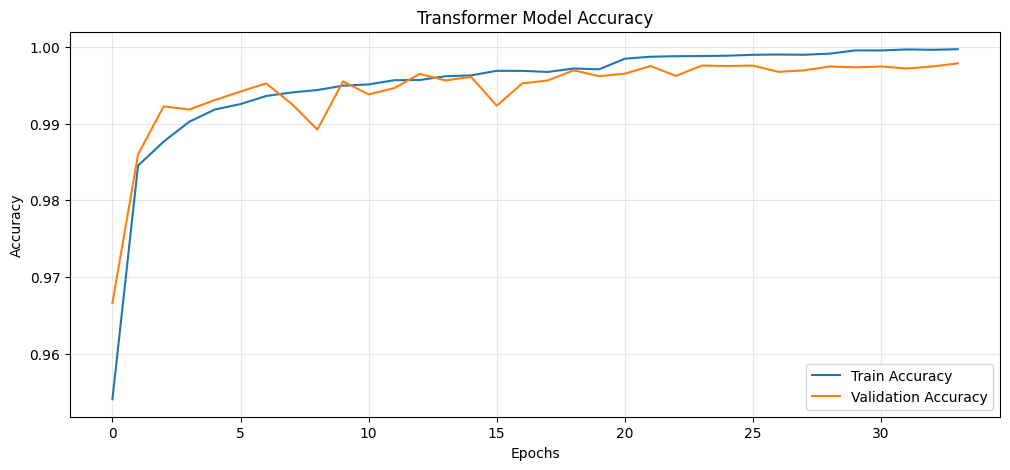

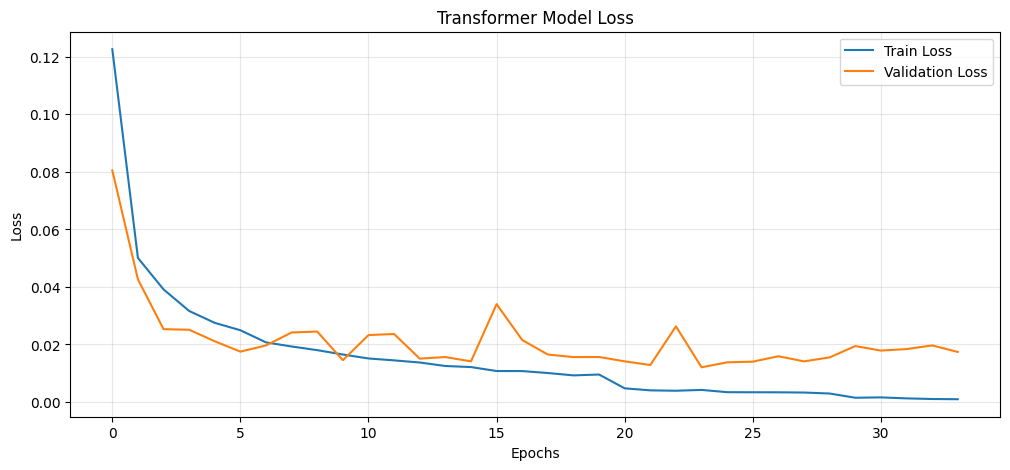

In [53]:
plt.figure(figsize=(12,5))
plt.plot(history_trans.history['accuracy'], label='Train Accuracy')
plt.plot(history_trans.history['val_accuracy'], label='Validation Accuracy')
plt.title("Transformer Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history_trans.history['loss'], label='Train Loss')
plt.plot(history_trans.history['val_loss'], label='Validation Loss')
plt.title("Transformer Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

===== Transformer Model Evaluation =====
Accuracy : 0.9976
Precision: 0.9976
Recall   : 0.9976
F1 Score : 0.9976

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     16920
           1       1.00      1.00      1.00     17072

    accuracy                           1.00     33992
   macro avg       1.00      1.00      1.00     33992
weighted avg       1.00      1.00      1.00     33992



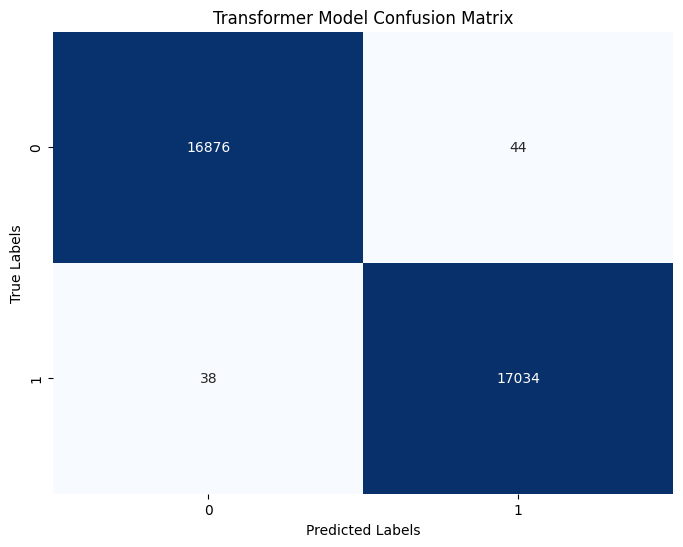

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred_probs = transformer_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

trans_acc = accuracy_score(y_true, y_pred)
trans_precision = precision_score(y_true, y_pred, average='weighted')
trans_recall = recall_score(y_true, y_pred, average='weighted')
trans_f1 = f1_score(y_true, y_pred, average='weighted')
trans_cm = confusion_matrix(y_true, y_pred)
trans_cr = classification_report(y_true, y_pred)

print("\n===== Transformer Model Evaluation =====")
print(f"Accuracy : {trans_acc:.4f}")
print(f"Precision: {trans_precision:.4f}")
print(f"Recall   : {trans_recall:.4f}")
print(f"F1 Score : {trans_f1:.4f}")
print("\nClassification Report:\n", trans_cr)

plt.figure(figsize=(8,6))
sns.heatmap(trans_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Transformer Model Confusion Matrix")
plt.show()


In [66]:
transformer_model.save("transformer_model.h5")

===== Detailed Model Performance Summary =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Transformer,0.997588,0.997588,0.997588,0.997588
1,Shallow Neural Network,0.997558,0.997564,0.997558,0.997558
2,XGBoost,0.993116,0.993121,0.993116,0.993116
3,SVM,0.991586,0.991633,0.991586,0.991586
4,KNN,0.983702,0.983713,0.983702,0.983702
5,Random Forest,0.981525,0.981681,0.981525,0.981524
6,CNN,0.951961,0.956177,0.951961,0.951853
7,Logistic Regression,0.882472,0.882547,0.882472,0.882467


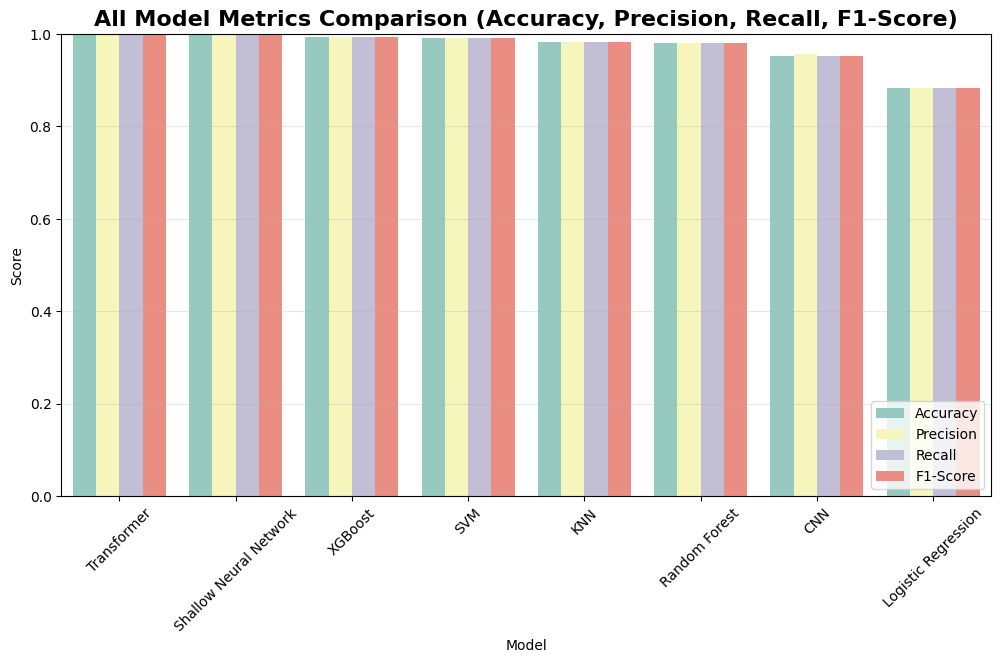

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

summary_data = []

for name, res in results.items():
    summary_data.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-Score": res["f1_score"]
    })

summary_data.append({
    "Model": "Shallow Neural Network",
    "Accuracy": nn_acc_without_scaled,
    "Precision": nn_precision_without_scaled,
    "Recall": nn_recall_without_scaled,
    "F1-Score": nn_f1_without_scaled
})

summary_data.append({
    "Model": "CNN",
    "Accuracy": nn_acc_cnn,
    "Precision": nn_precision_cnn,
    "Recall": nn_recall_cnn,
    "F1-Score": nn_f1_cnn
})

summary_data.append({
    "Model": "Transformer",
    "Accuracy": trans_acc,
    "Precision": trans_precision,
    "Recall": trans_recall,
    "F1-Score": trans_f1
})

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("===== Detailed Model Performance Summary =====")
display(summary_df)

summary_df_melted = summary_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                                    var_name="Metric", value_name="Value")
plt.figure(figsize=(12,6))
sns.barplot(data=summary_df_melted, x="Model", y="Value", hue="Metric", palette="Set3")
plt.ylim(0,1)
plt.title("All Model Metrics Comparison (Accuracy, Precision, Recall, F1-Score)", fontsize=16, fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(alpha=0.3, axis='y')
plt.show()

# General code for testing

In [61]:
import numpy as np
import librosa

def predict_audio_all_models(audio_path):
    audio, sample_rate = librosa.load(audio_path, res_type="kaiser_fast")
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    delta_mfcc = librosa.feature.delta(mfccs)
    delta2_mfcc = librosa.feature.delta(mfccs, order=2)
    combined_features = np.mean(np.vstack([mfccs, delta_mfcc, delta2_mfcc]).T, axis=0)
    X_ml = combined_features.reshape(1, -1)

    def extract_mel_spectrogram(file_path, n_mels=128, max_len=128):
        y, sr = librosa.load(file_path, sr=None)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)

        if mel_db.shape[1] < max_len:
            pad_width = max_len - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_db = mel_db[:, :max_len]

        return mel_db

    X_cnn = extract_mel_spectrogram(audio_path)[..., np.newaxis]
    X_cnn = np.expand_dims(X_cnn, axis=0) 

    def safe_argmax(pred):
        pred = np.array(pred)
        if pred.ndim == 1:
            return np.argmax(pred)
        else:
            return np.argmax(pred, axis=1)[0]

    def get_label(index):
        return next((k for k, v in label_mapping.items() if v == index), str(index))

    print("\n--- ML Model Predictions ---")
    for name, m in models.items():
        if name in scale_models:
            pred = m.predict(scaler.transform(X_ml))[0]
        else:
            pred = m.predict(X_ml)[0]
        label = get_label(pred)
        print(f"{name}: {label}")

    print("\n--- Shallow Neural Network Prediction ---")
    nn_pred_probs = model.predict(X_ml)
    nn_pred = safe_argmax(nn_pred_probs)
    label = get_label(nn_pred)
    print(f"Shallow NN: {label}")

    print("\n--- CNN Prediction ---")
    cnn_pred_probs = model_cnn.predict(X_cnn)
    cnn_pred = safe_argmax(cnn_pred_probs)
    label = get_label(cnn_pred)
    print(f"CNN: {label}")

    print("\n--- Transformer Prediction ---")
    trans_pred_probs = transformer_model.predict(X_ml)
    trans_pred = safe_argmax(trans_pred_probs)
    label = get_label(trans_pred)
    print(f"Transformer: {label}")

predict_audio_all_models("/kaggle/input/the-fake-or-real-dataset/for-original/for-original/testing/fake/file1.wav")


--- ML Model Predictions ---
Random Forest: FAKE
SVM: FAKE
Logistic Regression: FAKE
KNN: FAKE
XGBoost: FAKE

--- Shallow Neural Network Prediction ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
Shallow NN: FAKE

--- CNN Prediction ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
CNN: FAKE

--- Transformer Prediction ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Transformer: FAKE


In [62]:
for name, model in models.items():
    print(name)
    print(model)

Random Forest
RandomForestClassifier(random_state=42)
SVM
SVC(probability=True, random_state=42)
Logistic Regression
LogisticRegression(max_iter=1000, random_state=42)
KNN
KNeighborsClassifier()
XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)


In [63]:
import joblib

In [64]:
# # Save ML models
for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_model.pkl")
    print(f"Saved {name} model as {name.replace(' ', '_').lower()}_model.pkl")

Saved Random Forest model as random_forest_model.pkl
Saved SVM model as svm_model.pkl
Saved Logistic Regression model as logistic_regression_model.pkl
Saved KNN model as knn_model.pkl
Saved XGBoost model as xgboost_model.pkl


# Saving all the models

In [ ]:
# import joblib



# # Save scaler (if used)
# joblib.dump(scaler, "scaler.pkl")
# print("Saved scaler as scaler.pkl")

# # Save Shallow Neural Network
# model.save("shallow_nn_model.h5")
# print("Saved Shallow Neural Network as shallow_nn_model.h5")

# # Save CNN model
# model_cnn.save("cnn_model.h5")
# print("Saved CNN model as cnn_model.h5")

# # Save Transformer model
# transformer_model.save("transformer_model.h5")
# print("Saved Transformer model as transformer_model.h5")